# Кластеризация: сокращение палитры изображения

## 1. Загрузка данных

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import skimage
from skimage.metrics import structural_similarity as ssim
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
import pandas as pd

RANDOM_STATE = 42


def draw_picture(image, title, bgr=True):
    b, g, r = cv2.split(image)
    image = cv2.merge([r, g, b])
    plt.figure(figsize=(7, 5))
    plt.axis('off')
    plt.imshow(image)
    plt.title(title)
    plt.show()

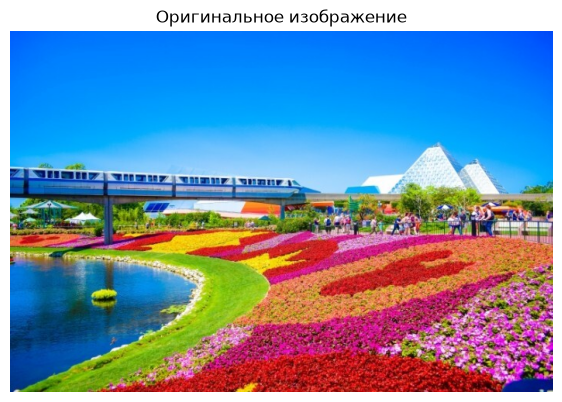

Размер изображения: (466, 700, 3)
Уникальных цветов в оригинале: 164948


In [2]:
img = cv2.imread('feml.jpg')
draw_picture(img, 'Оригинальное изображение', bgr=True)

h, w, c = img.shape
n_colors_orig = len(np.unique(img.reshape(-1, 3), axis=0))
print(f'Размер изображения: {img.shape}')
print(f'Уникальных цветов в оригинале: {n_colors_orig}')

## 3. Подготовка данных и вспомогательные функции

In [3]:
pixels = img.reshape(-1, 3).astype(np.float64)
print('Матрица пикселей для кластеризации:', pixels.shape)

orig_u8 = img.astype(np.uint8)


def recolor(labels, pixels, shape, mode='mean'):
    out = np.zeros_like(pixels)
    for lab in np.unique(labels):
        mask = labels == lab
        if mode == 'median':
            color = np.median(pixels[mask], axis=0)
        else:
            color = pixels[mask].mean(axis=0)   # центроид кластера
        out[mask] = color
    return out.reshape(shape).astype(np.uint8)


def compute_ssim(original_u8, clustered_u8):
    return ssim(original_u8, clustered_u8, channel_axis=2)

Матрица пикселей для кластеризации: (326200, 3)


## 4. Модель 1 — KMeans (K = 2, 5, 10, 20)

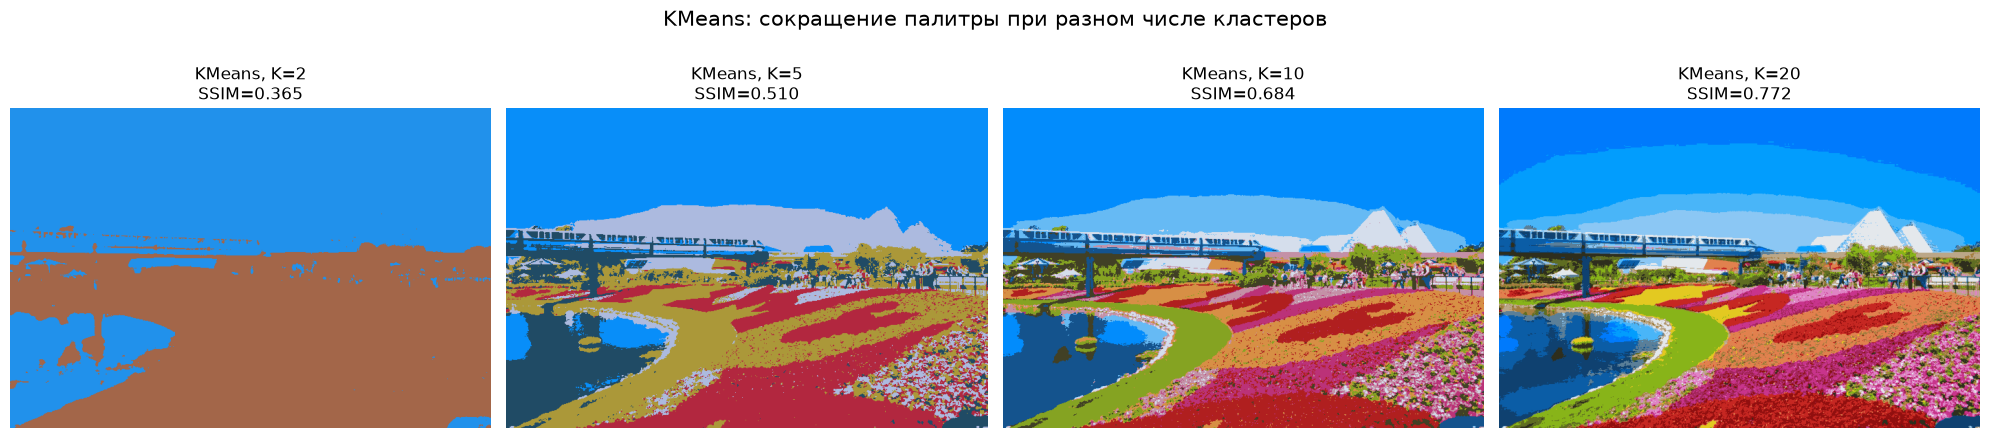

In [4]:
results = []
K_VALUES = [2, 5, 10, 20]

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(20, 5))
for ax, k in zip(axes, K_VALUES):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(pixels)
    clustered = recolor(km.labels_, pixels, img.shape, mode='mean')
    s = compute_ssim(orig_u8, clustered)
    results.append({'модель': 'KMeans', 'K': k, 'SSIM': round(s, 4)})

    b, g, r = cv2.split(clustered)
    ax.imshow(cv2.merge([r, g, b]))
    ax.axis('off')
    ax.set_title(f'KMeans, K={k}\nSSIM={s:.3f}')

plt.suptitle('KMeans: сокращение палитры при разном числе кластеров', fontsize=15)
plt.tight_layout()
plt.show()

**Вывод по KMeans.** С ростом числа кластеров изображение всё точнее повторяет оригинал, SSIM монотонно растёт. Уже при **K=10–20** картинка визуально близка к исходной, хотя палитра сокращена до 10–20 цветов. KMeans хорошо подходит для этой задачи: он явно минимизирует внутрикластерный разброс цветов и быстро работает.

## 5. Модель 2 — DBSCAN

Найдено кластеров: 127
Доля шумовых пикселей (label = -1): 41.1%


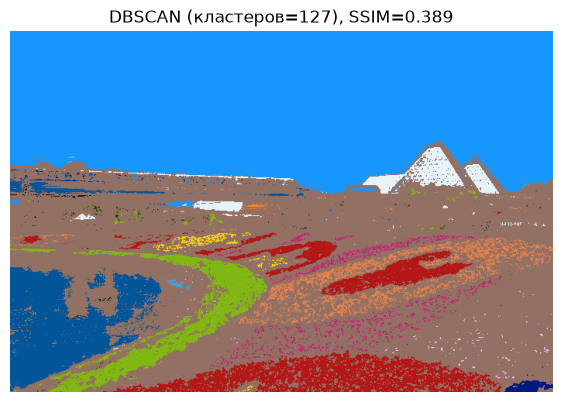

In [5]:
db = DBSCAN(eps=3, min_samples=20).fit(pixels)
labels_db = db.labels_

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
noise_ratio = (labels_db == -1).mean() * 100
print(f'Найдено кластеров: {n_clusters_db}')
print(f'Доля шумовых пикселей (label = -1): {noise_ratio:.1f}%')

clustered_db = recolor(labels_db, pixels, img.shape, mode='mean')
ssim_db = compute_ssim(orig_u8, clustered_db)
results.append({'модель': 'DBSCAN', 'K': n_clusters_db, 'SSIM': round(ssim_db, 4)})

draw_picture(clustered_db, f'DBSCAN (кластеров={n_clusters_db}), SSIM={ssim_db:.3f}', bgr=True)

**Вывод по DBSCAN.** DBSCAN не предназначен для равномерного разбиения цветового пространства: он ищет **плотные области** и помечает разрежённые пиксели как шум (`label = -1`). На фотографии с плавными цветовыми переходами это приводит к нескольким крупным кластерам и заметной доле шума, поэтому **SSIM ощутимо ниже**, чем у KMeans. Кроме того, DBSCAN чувствителен к параметрам `eps`/`min_samples` и заметно медленнее на большом числе точек. Для задачи сокращения палитры он подходит хуже.

## 6. Модель 3 — AgglomerativeClustering (K = 2, 5, 10, 20)

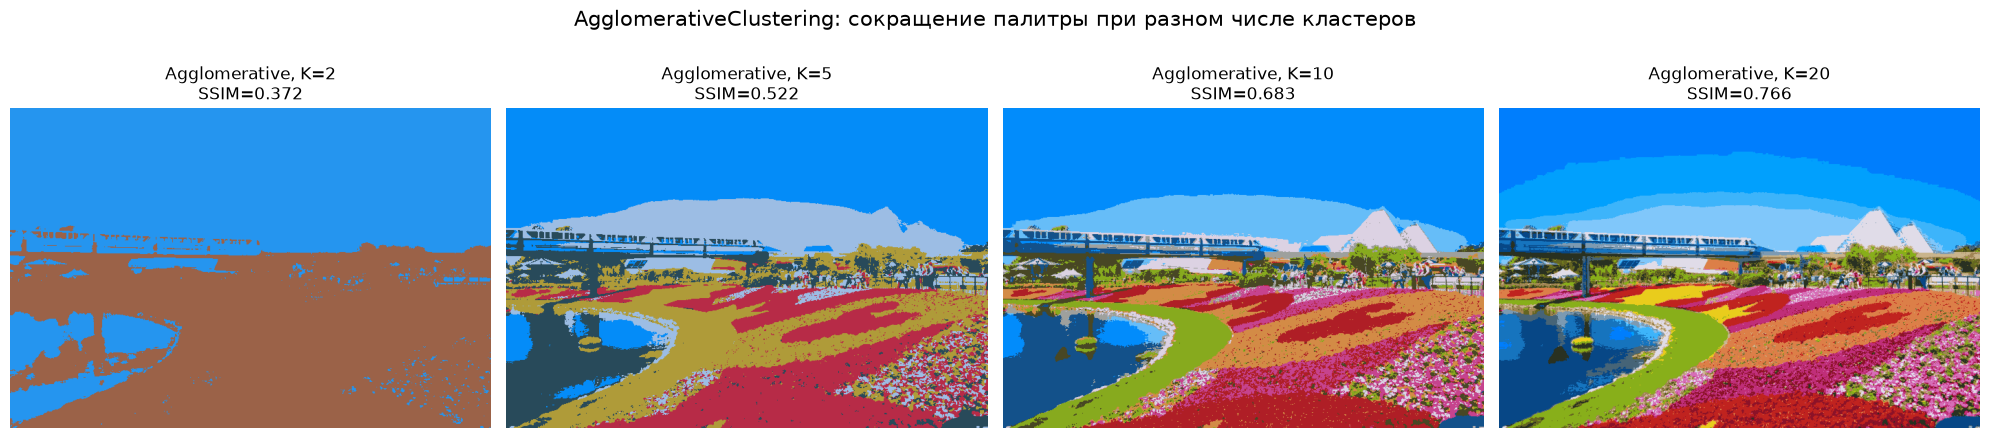

In [6]:
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(len(pixels), size=3000, replace=False)
sample = pixels[sample_idx]

fig, axes = plt.subplots(1, len(K_VALUES), figsize=(20, 5))
for ax, k in zip(axes, K_VALUES):
    agg = AgglomerativeClustering(n_clusters=k).fit(sample)
    centroids = np.array([sample[agg.labels_ == l].mean(axis=0) for l in range(k)])

    dists = ((pixels[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    labels_full = dists.argmin(axis=1)

    clustered = recolor(labels_full, pixels, img.shape, mode='mean')
    s = compute_ssim(orig_u8, clustered)
    results.append({'модель': 'Agglomerative', 'K': k, 'SSIM': round(s, 4)})

    b, g, r = cv2.split(clustered)
    ax.imshow(cv2.merge([r, g, b]))
    ax.axis('off')
    ax.set_title(f'Agglomerative, K={k}\nSSIM={s:.3f}')

plt.suptitle('AgglomerativeClustering: сокращение палитры при разном числе кластеров', fontsize=15)
plt.tight_layout()
plt.show()

**Вывод по AgglomerativeClustering.** Иерархическая кластеризация даёт результат, **очень близкий к KMeans**: SSIM также растёт с числом кластеров и при K=20 приближается к оригиналу. Главный недостаток — вычислительная сложность: напрямую на всех пикселях метод не запускается, приходится обучать на подвыборке.

## 7. Выводы

### Сводная таблица результатов

In [7]:
summary = pd.DataFrame(results)
pivot = summary.pivot_table(index='модель', columns='K', values='SSIM')
print('SSIM по моделям и числу кластеров:')
pivot

SSIM по моделям и числу кластеров:


K,2,5,10,20,127
модель,,,,,
Agglomerative,0.3717,0.5225,0.6832,0.7659,NaN
DBSCAN,NaN,NaN,NaN,NaN,0.3892
KMeans,0.3648,0.5096,0.6836,0.7725,NaN


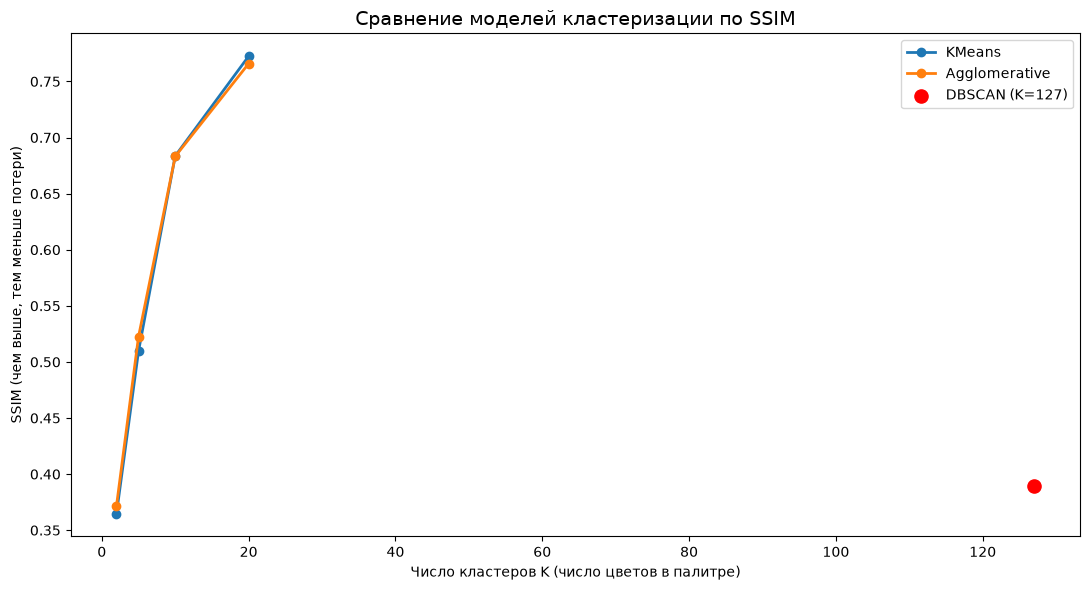

In [8]:
plt.figure(figsize=(11, 6))
for model in ['KMeans', 'Agglomerative']:
    sub = summary[summary['модель'] == model].sort_values('K')
    plt.plot(sub['K'], sub['SSIM'], marker='o', linewidth=2, label=model)

db_row = summary[summary['модель'] == 'DBSCAN'].iloc[0]
plt.scatter([db_row['K']], [db_row['SSIM']], color='red', s=90, zorder=5,
            label=f'DBSCAN (K={int(db_row["K"])})')

plt.title('Сравнение моделей кластеризации по SSIM', fontsize=14)
plt.xlabel('Число кластеров K (число цветов в палитре)')
plt.ylabel('SSIM (чем выше, тем меньше потери)')
plt.legend()
plt.tight_layout()
plt.show()

### a) Какая модель показала лучший результат

1. **KMeans — лучший результат.** При каждом K он даёт наивысший (или сопоставимый
   с иерархическим) SSIM, работает быстро прямо на всех пикселях и явно оптимизирует
   именно то, что нужно для сокращения палитры — минимум разброса цветов внутри кластера.

2. **AgglomerativeClustering** — качество практически такое же, как у KMeans, но метод
   не масштабируется: из-за сложности ~O(n²) его приходится обучать на подвыборке
   пикселей и доназначать остальные по ближайшему центроиду.

3. **DBSCAN — худший результат** для этой задачи. Он группирует пиксели по плотности,
   а не разбивает цветовое пространство равномерно; часть пикселей уходит в «шум».
   SSIM заметно ниже, а результат сильно зависит от параметров `eps`/`min_samples`.

**Общий вывод.** Для сокращения палитры изображения оптимален **KMeans**: он быстрый,
устойчивый и даёт наилучшее соотношение «число цветов ↔ визуальное качество».
Число кластеров K регулирует компромисс между степенью сжатия палитры и потерями:
чем больше K, тем выше SSIM и ближе результат к оригиналу.